(20631, 26)


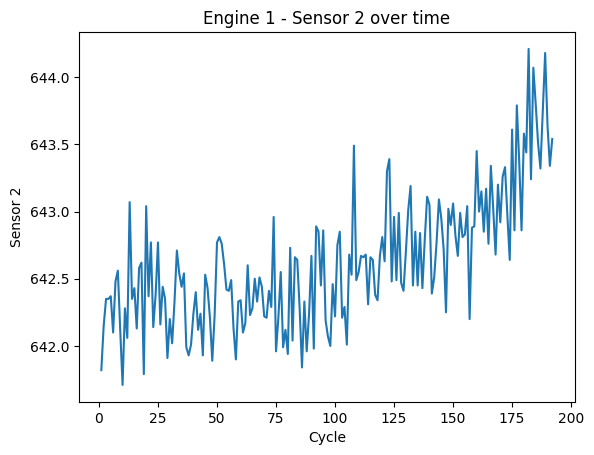

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
os.chdir(r'C:/Users/Giannis/.vscode/01_anomaly_detector')

columns = ['engine_id', 'cycle'] + \
          [f'setting_{i}' for i in range(1,4)] + \
          [f'sensor_{i}' for i in range(1,22)]

df = pd.read_csv('data/train_FD001.txt', sep='\s+', header=None, 
                  names=columns)
df.dropna(axis=1, inplace=True)

print(df.shape)
df.head()

engine_1 = df[df['engine_id'] == 1]
plt.plot(engine_1['cycle'], engine_1['sensor_2'])
plt.xlabel('Cycle')
plt.ylabel('Sensor 2')
plt.title('Engine 1 - Sensor 2 over time')
plt.savefig('C:/Users/Giannis/.vscode/01_anomaly_detector/results/engine1_sensor2.png')
plt.show()

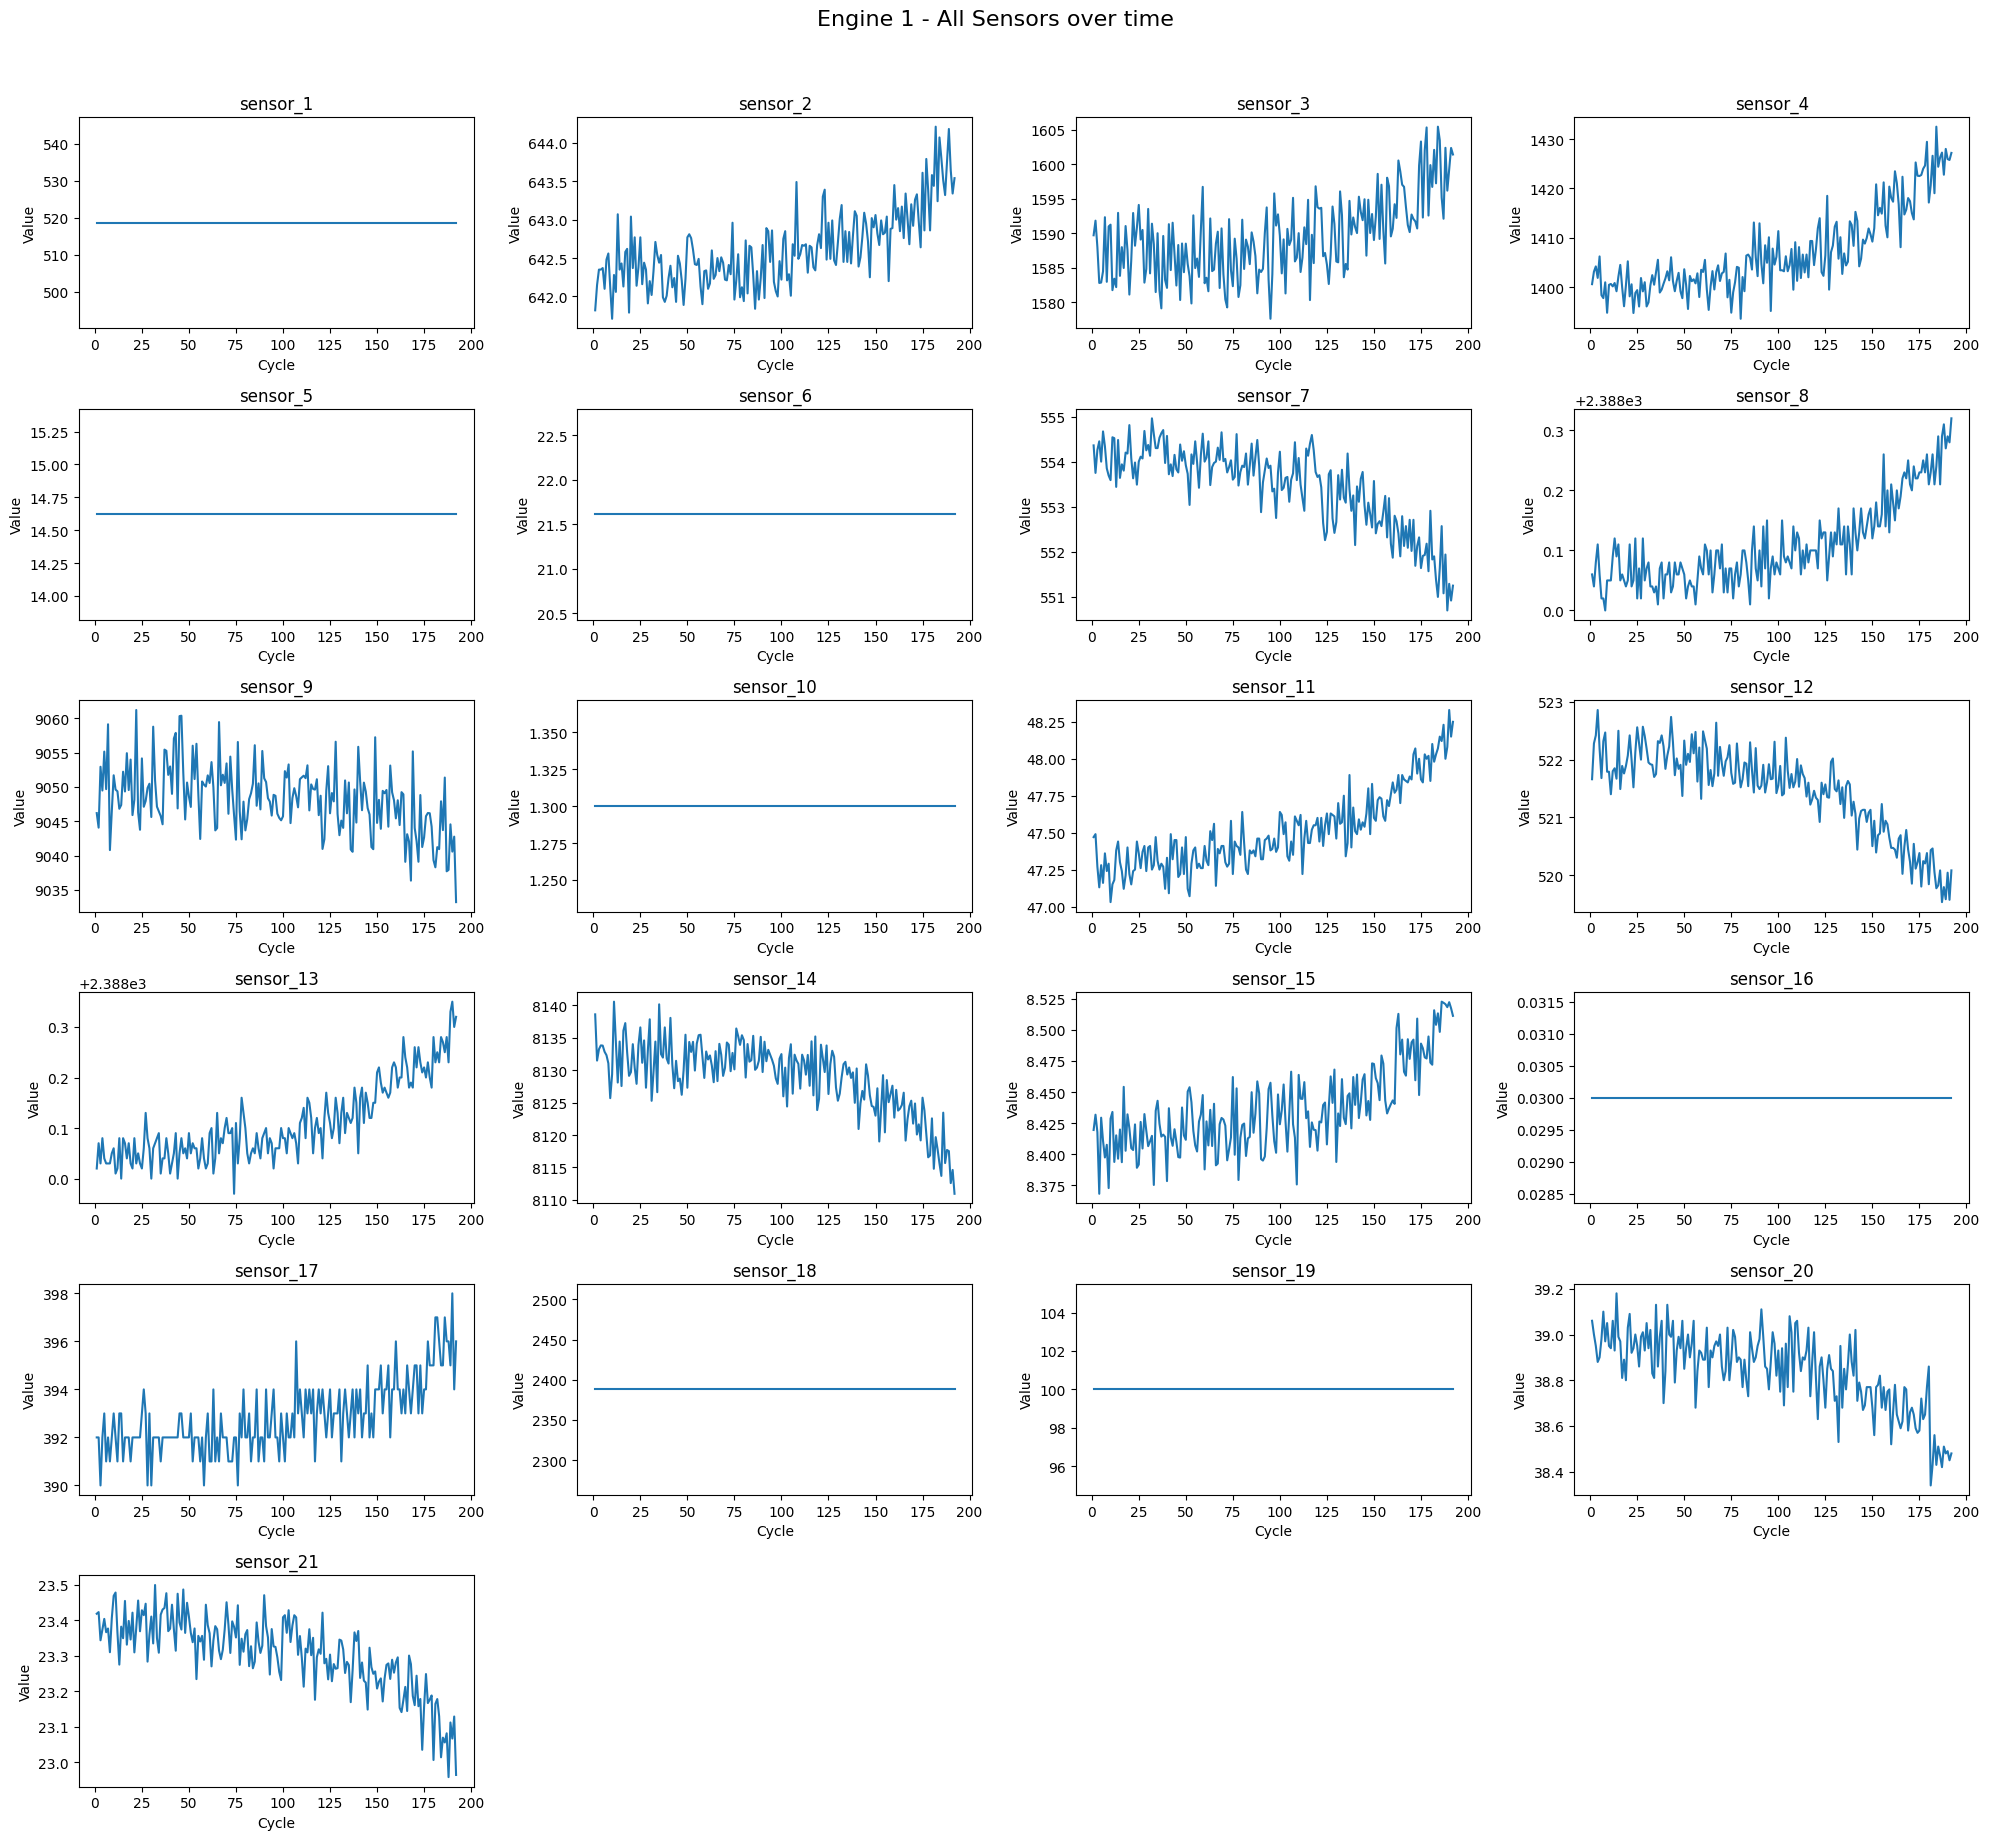

In [2]:
sensor_cols = [col for col in df.columns if col.startswith('sensor_')]

# Dynamically calculate grid size
n = len(sensor_cols)
ncols = 4
nrows = -(-n // ncols)  # ceiling division

engine_1 = df[df['engine_id'] == 1]

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, nrows * 3))
axes = axes.flatten()

for i, sensor in enumerate(sensor_cols):
    axes[i].plot(engine_1['cycle'], engine_1[sensor])
    axes[i].set_title(sensor)
    axes[i].set_xlabel('Cycle')
    axes[i].set_ylabel('Value')

# Hide any empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Engine 1 - All Sensors over time', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('C:/Users/Giannis/.vscode/01_anomaly_detector/results/engine1_all_sensors.png', bbox_inches='tight')
plt.show()

In [3]:
# Calculate max cycle per engine (= when it failed)
max_cycles = df.groupby('engine_id')['cycle'].max().reset_index()
max_cycles.columns = ['engine_id', 'max_cycle']

# Merge and calculate RUL
df = df.merge(max_cycles, on='engine_id')
df['RUL'] = df['max_cycle'] - df['cycle']

# Drop max_cycle column, no longer needed
df.drop(columns=['max_cycle'], inplace=True)

print(df[['engine_id', 'cycle', 'RUL']].head(10))
# engine 1 ran for 192 cycles total before failing

   engine_id  cycle  RUL
0          1      1  191
1          1      2  190
2          1      3  189
3          1      4  188
4          1      5  187
5          1      6  186
6          1      7  185
7          1      8  184
8          1      9  183
9          1     10  182


In [4]:
# Calculate standard deviation for each sensor
sensor_std = df[sensor_cols].std()
print(sensor_std.sort_index(key=lambda x: x.str.extract('(\d+)')[0].astype(int)))

sensor_1     0.000000e+00
sensor_2     5.000533e-01
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_5     5.329200e-15
sensor_6     1.388985e-03
sensor_7     8.850923e-01
sensor_8     7.098548e-02
sensor_9     2.208288e+01
sensor_10    0.000000e+00
sensor_11    2.670874e-01
sensor_12    7.375534e-01
sensor_13    7.191892e-02
sensor_14    1.907618e+01
sensor_15    3.750504e-02
sensor_16    3.469531e-18
sensor_17    1.548763e+00
sensor_18    0.000000e+00
sensor_19    0.000000e+00
sensor_20    1.807464e-01
sensor_21    1.082509e-01
dtype: float64


In [5]:
# Drop flat/useless sensors
flat_sensors = ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 
                'sensor_16', 'sensor_18', 'sensor_19']
df.drop(columns=flat_sensors, inplace=True)

# Update sensor_cols
sensor_cols = [col for col in df.columns if col.startswith('sensor_')]

print(f'Remaining sensors: {len(sensor_cols)}')
print(sensor_cols)

Remaining sensors: 14
['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [6]:
from sklearn.model_selection import train_test_split

# Define features and target
X = df[sensor_cols]
y = df['RUL']

# Split into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f'Training samples: {len(X_train)}')
print(f'Test samples: {len(X_test)}')

Training samples: 16504
Test samples: 4127


In [7]:
from sklearn.ensemble import RandomForestRegressor

# Train the model
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print('Model trained!')

Model trained!


In [8]:
from sklearn.metrics import mean_absolute_error, r2_score

# Make predictions
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error: {mae:.1f} cycles')
print(f'R² Score: {r2:.3f}')

Mean Absolute Error: 29.5 cycles
R² Score: 0.626


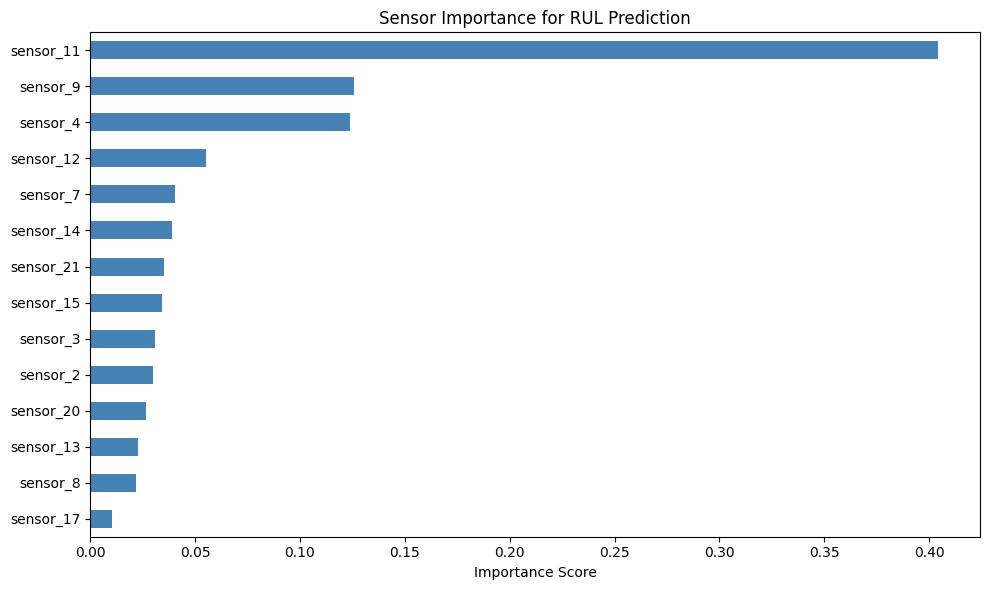

In [9]:
# Feature importance plot
importances = pd.Series(model.feature_importances_, index=sensor_cols)
importances.sort_values().plot(kind='barh', figsize=(10, 6), color='steelblue')
plt.title('Sensor Importance for RUL Prediction')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('results/feature_importance.png', bbox_inches='tight')
plt.show()

In [10]:
# Rolling average over last 10 cycles per engine
df = df.sort_values(['engine_id', 'cycle'])

for sensor in sensor_cols:
    df[f'{sensor}_rolling_mean'] = df.groupby('engine_id')[sensor]\
        .transform(lambda x: x.rolling(window=10, min_periods=1).mean())

print('Rolling features added!')
print(df.shape)

Rolling features added!
(20631, 34)


In [11]:
# Update feature set to include rolling means
feature_cols = sensor_cols + [f'{s}_rolling_mean' for s in sensor_cols]

X = df[feature_cols]
y = df['RUL']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)
mae2 = mean_absolute_error(y_test, y_pred2)
r2_2 = r2_score(y_test, y_pred2)

print(f'Mean Absolute Error: {mae2:.1f} cycles')
print(f'R² Score: {r2_2:.3f}')
print(f'\nImprovement in R²: {r2_2 - r2:.3f}')
print(f'Improvement in MAE: {mae - mae2:.1f} cycles')

Mean Absolute Error: 19.1 cycles
R² Score: 0.827

Improvement in R²: 0.201
Improvement in MAE: 10.4 cycles


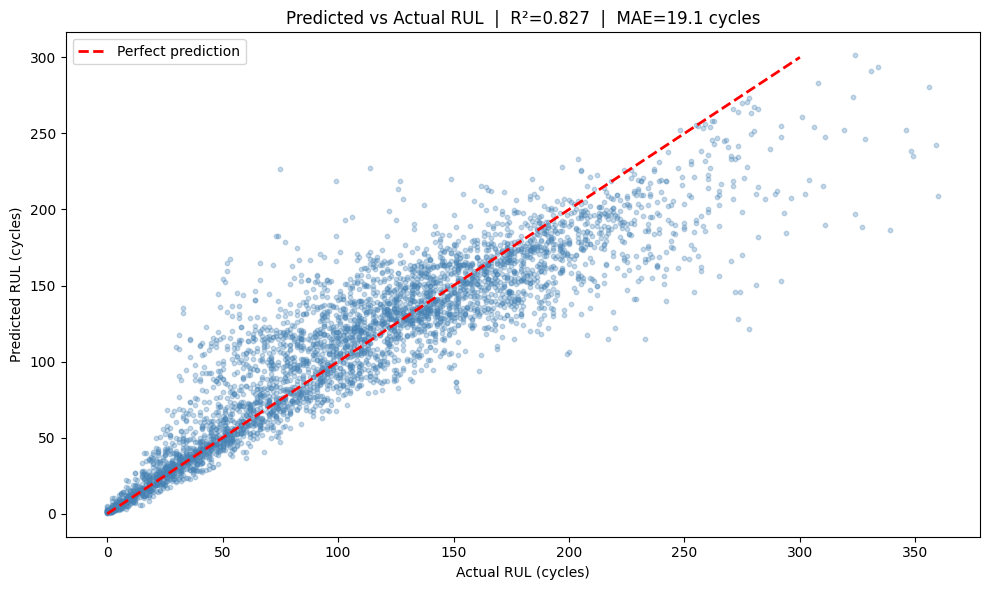

In [12]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred2, alpha=0.3, color='steelblue', s=10)
plt.plot([0, 300], [0, 300], 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual RUL (cycles)')
plt.ylabel('Predicted RUL (cycles)')
plt.title(f'Predicted vs Actual RUL  |  R²={r2_2:.3f}  |  MAE={mae2:.1f} cycles')
plt.legend()
plt.tight_layout()
plt.savefig('results/predictions_vs_actual.png', bbox_inches='tight')
plt.show()